In [7]:
import sys 
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import BallTree



sys.path.append(os.path.abspath(".."))
from src.config import OPERATOR_COLORS

DATA_PATH = os.path.join("..", "data", "processed", "cleaned_bd_cells.parquet")
df = pd.read_parquet(DATA_PATH)
print(f"Loaded {len(df):,} cleaned records.")

lte_df = df[df["radio"] == "LTE"].copy()


def compute_operator_isd(data, earth_radius_km = 6371):
    results = []
    for operator_name in data["operator"].unique():
        sub = data[data["operator"] == operator_name].copy()
        if len(sub) < 2:
            continue
        coords_rad = np.radians(sub[["lat", "lon"]].values)

        tree = BallTree(coords_rad, metric= "haversine")

        distances, _ = tree.query(coords_rad, k = 2)

        sub["isd_km"] = distances [ :, 1] * earth_radius_km
        results.append(sub)

    return pd.concat(results, ignore_index=True)

lte_isd_df = compute_operator_isd(lte_df)


isd_summary = lte_isd_df.groupby("operator", observed = False)["isd_km"].agg(
    Total_LTE_Cells = "count",
    Median_ISD_km = "median",
    Mean_ISD_km = "mean",
    P25_ISD_km = lambda x: x.quantile(0.25),
    P75_ISD_km = lambda x: x.quantile(0.75)
).round(2).sort_values(by = "Median_ISD_km")

print("\n === INTER-SITE DISTANCE (ISD) BENCHMARK (LTE) ===")
display(isd_summary)

Loaded 8,945 cleaned records.

 === INTER-SITE DISTANCE (ISD) BENCHMARK (LTE) ===


,Total_LTE_Cells,Median_ISD_km,Mean_ISD_km,P25_ISD_km,P75_ISD_km
operator,,,,,
Grameenphone,2746,0.07,0.36,0.02,0.20
Robi,1545,0.07,0.55,0.02,0.18
Banglalink,2434,0.08,0.31,0.03,0.20
Teletalk,654,0.08,0.50,0.02,0.19


/tmp/ipykernel_7988/2557997392.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


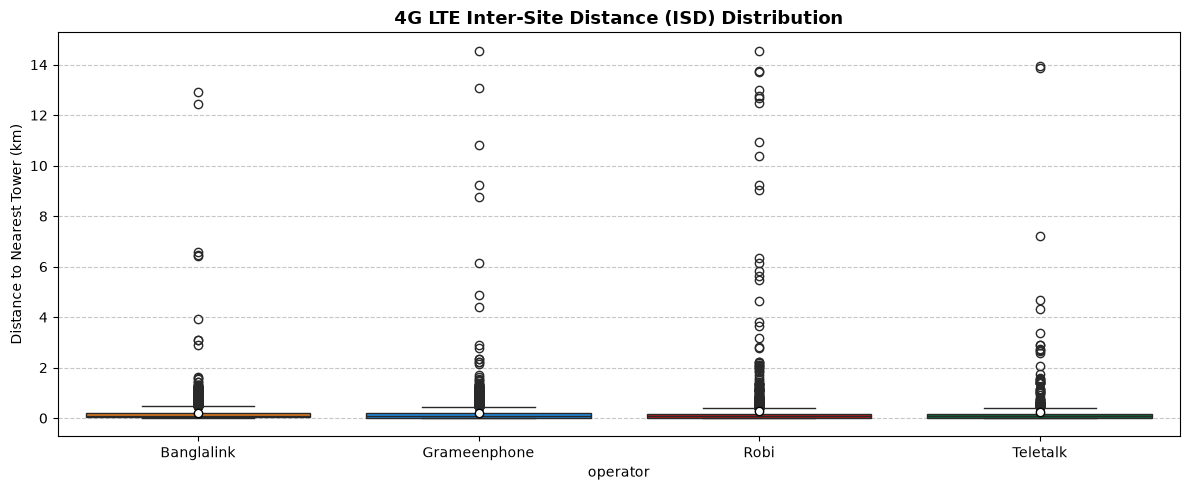

In [12]:
plt.figure(figsize=(12, 5))

filtered_isd = lte_isd_df[lte_isd_df["isd_km"] < 15.0]

sns.boxplot(
    data = filtered_isd,
    x = "operator",
    y = "isd_km",
    palette = OPERATOR_COLORS,
    showmeans = True,
    meanprops = {"marker": "o", "markerfacecolor": "white", "markeredgecolor": "black"}

)

plt.title("4G LTE Inter-Site Distance (ISD) Distribution", fontsize = 13, weight = "bold")
plt.xlabel("operator")
plt.ylabel("Distance to Nearest Tower (km)")
plt.grid(axis= "y", linestyle = "--", alpha = 0.7)
plt.tight_layout()
plt.show()